# Gradient verification for the 1D - non reactive transport (diffusion + advection), permeablity inversion 

The goal here is to verify the correctness of the adjoint state method in HYTEC by comparing the results with the demonstrator's which are considered as correct.

In [1]:
import os
from pathlib import Path
import logging
import copy
import time
from typing import Dict, Generator, Iterable
import pyrtid
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
import hytecio
import nested_grid_plotter
from nested_grid_plotter import (
    NestedGridPlotter,
    AnimatedPlotter,
    extract_frames_from_embedded_html_animation,
    multi_imshow,
)

# from pyesmda.esmda
from hytecio.core import (
    AdjustableParameter,
    HytecSimulation,
    ParameterFiles,
    Observable,
    ObservationType,
)

from hytecio.job_managers import (
    FrontalHytecRunner,
    JobConfig,
    SlurmHytecRunner,
    QsubHytecRunner,
)
import hytecio.core.model as hymd
from hytecio.utils import (
    StrEnum,
    is_tool,
    get_hytec_version,
    get_mpi_version,
    indices_to_hytec_node_number,
    gen_random_ensemble,
    get_normalized_mean_from_lognormal_params,
    get_normalized_std_from_lognormal_params,
)
from hytecio.plot import plot_observed_vs_simulated
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.animation import HTMLWriter
from IPython.display import HTML
import numpy as np
import numpy.typing as npt
import pandas as pd
from scipy.ndimage import gaussian_filter
import gstools as gs
from pyrtid.utils import NDArrayFloat, NDArrayInt

gs.config.USE_RUST = True  # Use the rust implementation of gstools

- Set-up logging level

In [3]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("this is a logging test")

INFO:root:this is a logging test


- Check package/software versions(slurm = clusterfon, qsub = Omines, frontal = local machine)
- Check package/software versions

In [4]:
logging.info(f"hytecio version = {hytecio.__version__}")
logging.info(f"nested_grid_plotter version = {nested_grid_plotter.__version__}")
logging.info(f"pyrtid version = {pyrtid.__version__}")


class RunnerType(StrEnum):
    FRONTAL = "frontal"
    QSUB = "qsub"
    SLURM = "slurm"
    UNKNOWN = "unknown"


hytec_paths = {
    RunnerType.FRONTAL: "hytec",
    RunnerType.QSUB: "/omines/home/public/Programs/HYTEC/hytec-4.7.4",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/acollet/hytec/svn/build/bin/Release/hytec",
}

v = ""
runner_type = RunnerType.UNKNOWN
for k, v in hytec_paths.items():
    if is_tool(v):
        runner_type = k
        break

if runner_type == RunnerType.UNKNOWN:
    raise Exception("no valid hytec command found !")

# Path or alias to the hytec binary on your local machine.
hytec_binary_path_or_alias: str = v

logging.info(f"HYTEC version = {get_hytec_version(hytec_binary_path_or_alias)}")

mpi_binary_path_or_alias: str = {
    RunnerType.FRONTAL: "mpiexec",
    RunnerType.QSUB: "mpiexec",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/apps/mpich/4.0.2/bin/mpiexec",
}[runner_type]

logging.info(f"mpiexec version = {get_mpi_version(mpi_binary_path_or_alias)}")

dos2unix_binary_path_or_alias = "dos2unix"

INFO:root:hytecio version = 0.1.5
INFO:root:nested_grid_plotter version = 0.1.0
INFO:root:pyrtid version = 0.1.0

INFO:root:HYTEC version = 4.7.4-r1663
INFO:root:mpiexec version = 4.1.1


- Create a directory to store the exported figures

In [5]:
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
fig_save_path = Path(ipynb_path, "exported_figures")
fig_save_path.mkdir(parents=True, exist_ok=True)  # make sure that the directory exists

- Define some configurations for the plots

In [6]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # required for the plot to update
plt.rcParams.update(new_rc_params)

## Forward problem

- Define a very simple pure advection - diffusion case in 1D.

In [7]:
nx = 40  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
# Give non regular dimensions to check if all is correct with mesh dimensions
dx = 7.22  # voxel dimension along the x axis
dy = 6.66  # voxel dimension along the y axis
nt = 15  # number of time steps
dt = 3600  # timestep in seconds
c0 = 0  # general initial cocentration
# Hydro parameters
D0 = 1e-20  # general initial diffusion coefficient [m2/s]
k0 = 1e-3  # general permeability
w0 = 0.23  # general porosity [fraction]
# Chemistry parameters
c0 = 0.0  # general initial concentration [molal]
c_inj = 1e-5  # molal

storage_coefficient: float = 1e-3

cst_head_left = 9.3  # m
cst_head_right = -5.5  # m

flow_regime = "transient"

crank_flow = 0.7
crank_diff = 0.9
crank_adv = 0.5

# Values for the x axis ()meters
x_positions_in_meters: NDArrayFloat = np.arange(nx) * dx + dx / 2

- Three observation wells

In [8]:
production_locations = [12, 28]
injection_locations = [4, 20, 36]

- Create an initial "bumped" reference distribution for the permeability, and a flat one for the initial estimation.

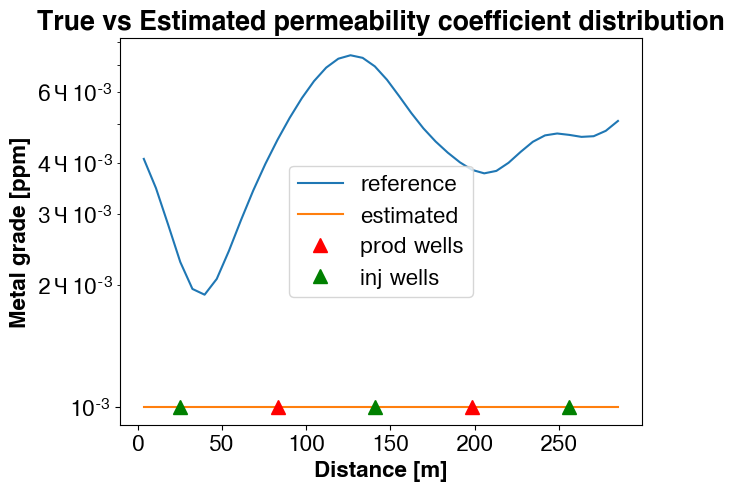

In [9]:
# Create a Gaussian Covariance Model just for the example
# To vary the results, change the seed :)
seed = 6

min_val = 1e-3
max_val = 1e-2
# Compute the mean and the standard deviation that the distribution should have so that
# <99% of the values are between min and max ~ 6 sigmas
mean = (max_val + min_val) / 2.0
stdev = (max_val - min_val) / 3.0 / 2.0  # std ~ 1/6 of the distribution interval
len_scale: float = 5.0

perm_reference = gen_random_ensemble(
    model=gs.covmodel.Gaussian,
    n_ensemble=1,
    var=stdev**2,
    len_scale=len_scale,
    mean=mean,
    nx=nx,
    ny=ny,
    seed=seed,
)[0, :, :, 0]


# Initial estimate = an homogeneous value
perm_estimate = np.ones((nx, ny)) * min_val  # m2/s

plotter = NestedGridPlotter()
ax = plotter.ax_dict["ax1-1"]

ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Metal grade [ppm]", fontweight="bold")
ax.set_yscale("log")
ax.set_title(
    "True vs Estimated permeability coefficient distribution", fontweight="bold"
)
plotter.fig.set_facecolor("w")


ax.plot(x_positions_in_meters, perm_reference, label="reference")
ax.plot(x_positions_in_meters, perm_estimate, label="estimated")

# Add some vertical lines to indicate the well
for well_pos in production_locations:
    ax.plot(
        well_pos * dx - dx / 2,
        min_val,
        label="prod wells",
        marker="^",
        markersize=10,
        c="r",
        linestyle="none",
    )

for well_pos in injection_locations:
    ax.plot(
        well_pos * dx - dx / 2,
        min_val,
        label="inj wells",
        marker="^",
        markersize=10,
        c="g",
        linestyle="none",
    )

plotter.add_axis_legend("ax1-1")

fname = "true_vs_estimated_initial_mineral_field"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Note: The initial concentration is the same in both cases and has a blocky shape.

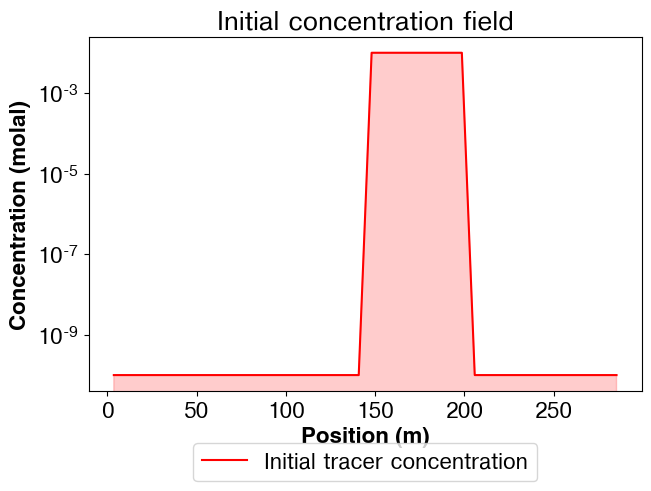

In [10]:
zone_high_conc_start = 20
zone_high_conc_stop = 28

c_min = 1e-10  # [mol/kg]
c_max = 1e-2  # [mol/kg]
c_init = np.ones((nx)) * c_min
c_init[zone_high_conc_start:zone_high_conc_stop] = c_max

plotter = NestedGridPlotter()
plotter.ax_dict["ax1-1"].plot(
    np.arange(nx) * dx + dx / 2,
    c_init,
    label="Initial tracer concentration",
    color="red",
)
plotter.ax_dict["ax1-1"].fill_between(
    np.arange(nx) * dx + dx / 2,
    0.0,
    c_init,
    alpha=0.2,
    color="red",
)
plotter.ax_dict["ax1-1"].set_xlabel("Position (m)", weight="bold")
plotter.ax_dict["ax1-1"].set_ylabel("Concentration (molal)", weight="bold")
plotter.ax_dict["ax1-1"].set_yscale("log")
plotter.ax_dict["ax1-1"].legend(loc="center", bbox_to_anchor=(0.5, -0.2), ncol=2)
plotter.ax_dict["ax1-1"].set_title("Initial concentration field")
plotter.fig.set_facecolor("w")

fname = "initial_tracer_concentration"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

- Create the flowrates for the wells: 12 m3/h decreasing following an exponential... for the producers with a balanced injection (2 m3/h per associated cell for the injectors).

In [11]:
def gen_flowrates(amplitude: float, coef: float, nt: int, dt: float) -> NDArrayFloat:
    """Generate flowrates with a given amplitude and decrease coefficient.

    Parameters
    ----------
    amplitude : float
        Amplitude in m3/h.
    coef : float
        Decrease coefficient.
    nt : int
        Number of timesteps
    dt : float
        Timesteps.

    Returns
    -------
    np.ndarray
        The flowrates.
    """
    return amplitude * np.exp(coef * np.arange(nt) * dt)

- Generate a flowrates with an initial amplitude at 1 m3/h and plot it

Text(0.5, 0, 'time [d]')

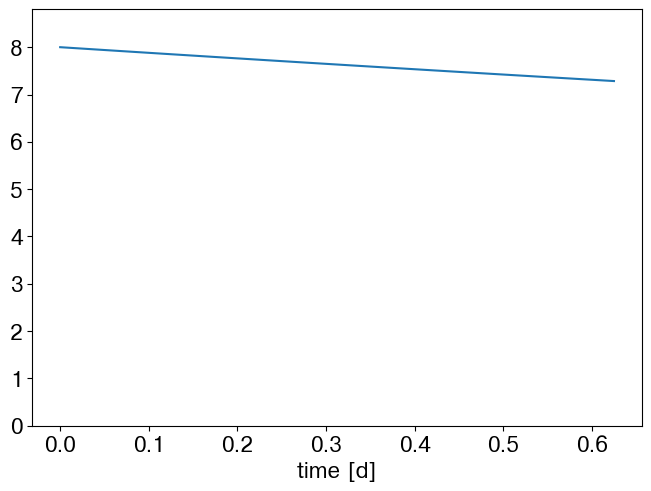

In [12]:
init_prod_flowrates = 8.0  # m3/s
# nt+1 because we consider the initial state too
flowrates = init_prod_flowrates * gen_flowrates(
    1.0, -0.15, nt + 1, dt=dt / 3600 / 24
)  # m3/s

plt.plot(np.arange(nt + 1) * dt / 3600 / 24, flowrates)
plt.ylim(0.0, init_prod_flowrates * 1.1)
plt.xlabel("time [d]")

### Forward problem in demonstrator

- For c_init, need to apply nx+1 in the case of the finite differences for the parameters because of the spatial discretization scheme (finite differences and finite volumes respectively).

In [13]:
time_params = dmfwd.TimeParameters(nt=nt, dt_init=dt)
geometry = dmfwd.Geometry(nx=nx, ny=ny, dx=dx, dy=dy)
fl_params = dmfwd.FlowParameters(
    permeability=k0,
    storage_coefficient=storage_coefficient,
    regime={
        "stationary": dmfwd.FlowRegime.STATIONARY,
        "transient": dmfwd.FlowRegime.TRANSIENT,
    }[flow_regime],
    crank_nicolson=crank_flow,
)
tr_params = dmfwd.TransportParameters(
    diffusion=D0,
    porosity=w0,
    crank_nicolson_diffusion=crank_diff,
    crank_nicolson_advection=crank_adv,
)
gch_params = dmfwd.GeochemicalParameters(conc=c0)

base_model = dmfwd.ForwardModel(geometry, time_params, fl_params, tr_params, gch_params)

- Add boundary conditions

In [14]:
# Boundary conditions
base_model.add_boundary_conditions(dmfwd.ConstantHead(span=(slice(0, 1), slice(None))))
base_model.fl_model.head[0, :, :] = cst_head_left
base_model.add_boundary_conditions(
    dmfwd.ConstantHead(span=(slice(nx - 1, nx), slice(None)))
)
base_model.fl_model.head[-1, :, :] = cst_head_right

- Add source and sink terms

In [15]:
prod_flw = -flowrates / 3600  # m3/h to m3/s
times = np.arange(stop=nt + 1, start=0) * dt

# two successive pumping on days 1 and 2
for loc in production_locations:
    sink_term = dmfwd.SourceTerm(
        f"producer loc # {loc}",
        node_ids=np.array([loc]),
        # pumping on 1 day
        times=times,
        flowrates=prod_flw,
        concentrations=np.zeros(times.shape),
    )
    base_model.add_src_term(sink_term)

n_prod_linked_list = [1, 2, 1]

# three successive injections on days 3, 4 and 5
for count_inj, loc in enumerate(injection_locations):
    source_term = dmfwd.SourceTerm(
        "injector loc # {loc}",
        node_ids=np.array([loc]),
        times=times,
        flowrates=-n_prod_linked_list[count_inj] * prod_flw / 2,
        concentrations=np.ones(times.shape) * c_inj,  # injection concentration
    )
    base_model.add_src_term(source_term)

- Create two models

In [16]:
model_reference = copy.deepcopy(base_model)
model_estimate = copy.deepcopy(base_model)
# Reference
model_reference.fl_model.permeability = perm_reference.reshape(nx, ny)
# Estimated diffusion
model_estimate.fl_model.permeability = perm_estimate.reshape(nx, ny)
model_reference.tr_model.conc[:, :, 0] = c_init.reshape(nx, ny)
model_estimate.tr_model.conc[:, :, 0] = c_init.reshape(nx, ny)

- Run the models

In [17]:
solver_reference = dmfwd.ForwardSolver(model_reference)
solver_reference.solve()

In [18]:
solver_estimate = dmfwd.ForwardSolver(model_estimate)
solver_estimate.solve()

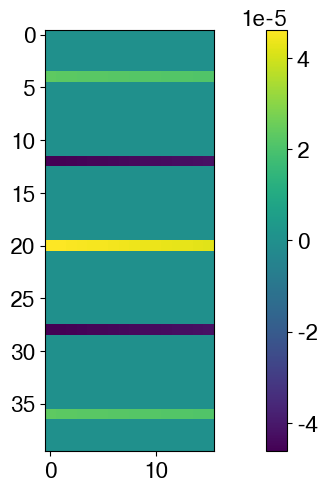

In [19]:
plt.imshow(model_reference.fl_model.sources[:, 0, :])
plt.colorbar()

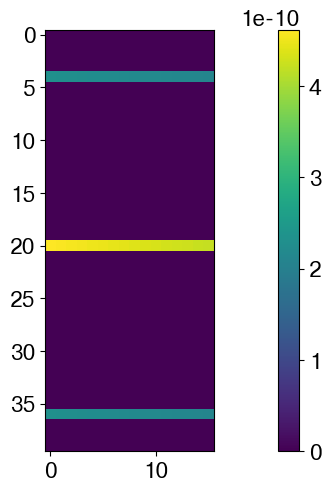

In [20]:
plt.imshow(model_reference.tr_model.sources[:, 0, :])
plt.colorbar()

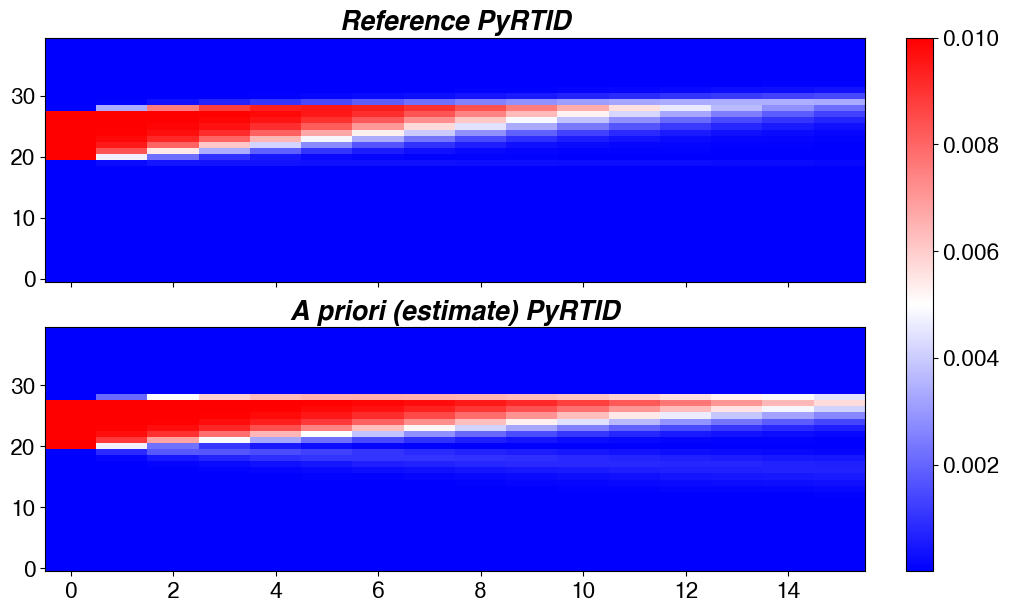

In [21]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 6)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax2-1"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        "Reference PyRTID": model_reference.tr_model.conc[:, 0, :].T,
        "A priori (estimate) PyRTID": model_estimate.tr_model.conc[:, 0, :].T,
    },
)

fname = "tracer_concentration_true_vs_estimate_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

### Forward problem definition in HYTEC

- Create an empty simulation in a non existing folder

In [22]:
simu_base = HytecSimulation("simu_base", Path.cwd().joinpath("simu_base"))

- Add a TDB file

In [23]:
simu_base.link_tdb("./../../../../../TDB/chess.tdb")  # This is relative to the htc file

- Define the output format

In [24]:
simu_base.model.add_sub_item(hymd.OutputFormat("vtk"))

- Hydrodynamic model and its parameters definition


In [25]:
hmodel = hymd.HydrodynamicModel(
    hymd.FlowRegime(flow_regime),
    hymd.Porosity(w0),
    hymd.Permeability(k0, units="m/s"),
    hymd.DiffusionCoefficient(D0, units="m2/s"),
    hymd.Head(0.0, "m"),
    hymd.FlowCrankNicolson(crank_flow),
    hymd.AdvectionCrankNicolson(crank_adv),
    hymd.DiffusionCrankNicolson(crank_diff),
    hymd.StorageCoefficient(storage_coefficient),
)
simu_base.model.add_sub_item(hmodel)

- Geochemical unit definition

In [26]:
chmodel = hymd.GeochemicalModel(hymd.Report("full"), hymd.Redox("disabled"))
# Define a geochem unit
base_unit = hymd.GeochemicalUnit("chem_base")
high_conc_unit = hymd.GeochemicalUnit("chem_high_conc")
inj_unit = hymd.GeochemicalUnit("injected_solution")
species = "T"
# Set concentrations
base_unit.add_sub_item(hymd.Concentration(species, c_min, units="molal"))
high_conc_unit.add_sub_item(hymd.Concentration(species, c_max, units="molal"))
inj_unit.add_sub_item(hymd.Concentration(species, c_inj, units="molal"))
# define tracer
chmodel.add_sub_item(hymd.Define("basis", species))

# exclude
chmodel.add_sub_item(hymd.Exclude(("minerals", "colloids", "gases")))

# Add the units to the geochemical model
chmodel.add_sub_item(base_unit)
chmodel.add_sub_item(high_conc_unit)
chmodel.add_sub_item(inj_unit)

# Add to the main model
simu_base.model.add_sub_item(chmodel)

- Geometry definition

In [27]:
gmodel = hymd.GeometryModel(
    hymd.GridRegime("rectangle"), hymd.Domain(f"{nx*dx},{nx} {ny*dy},{ny}")
)
zone_domain = hymd.Zone(
    "domain", hymd.Geometry("domain"), hymd.Geochemistry(base_unit.name)
)

zone_high_conc_span = zone_high_conc_stop - zone_high_conc_start
zone_high_conc_center = zone_high_conc_start + zone_high_conc_span / 2
zone_high_conc = hymd.Zone(
    "zone_high_conc",
    hymd.Geometry(
        f"rectangle {zone_high_conc_center  * dx},{dy / 2} {zone_high_conc_span * dx},{dy} m"
    ),
    hymd.Geochemistry(high_conc_unit.name),
)
gmodel.add_sub_item(zone_domain)
gmodel.add_sub_item(zone_high_conc)
simu_base.model.add_sub_item(gmodel)

- Boundary model definition

In [28]:
flc_left = hymd.FlowCondition(f"constant-head at {cst_head_left} m")
flc_right = hymd.FlowCondition(f"constant-head at {cst_head_right} m")
bmodel = hymd.BoundaryModel(
    hymd.Boundary(
        "border_left", hymd.Coordinates(f"0,0, 0,{ny*dy}", units="m"), flc_left
    ),
    hymd.Boundary(
        "border_right",
        hymd.Coordinates(f"{nx*dx},{ny*dy}, {nx*dx},0", units="m"),
        flc_right,
    ),
)
simu_base.model.add_sub_item(bmodel)

- Time discretization

In [29]:
tmodel = hymd.TimeDiscretizationModel(
    hymd.Duration(nt * dt, units="s"),
    hymd.TimeStep(
        hymd.Variable(
            hymd.StartValue(dt, "s"), hymd.Maximum(dt, "s"), hymd.CourantFactor(20.0)
        ),
    ),
)
simu_base.model.add_sub_item(tmodel)

- Sampling definition

In [30]:
# Sampling model
smodel = hymd.SamplingModel(
    hymd.GridSampling(nt),
    hymd.Select("time", units="s"),
    hymd.Select("node-number"),
    hymd.Select("flowrate", units="m/s"),
    hymd.Select("permeability", units="m/s"),
    hymd.Select("head", units="m"),
    hymd.Select("porosity"),
    hymd.Select("diffusion"),
    hymd.Select("T", units="mol/kg"),
)
simu_base.model.add_sub_item(smodel)

- Create the injection/pumping file: 1 column per well + 1 column for the time (days)

In [31]:
src_term_path: str = "MODIFY/source_terms.dat"
src_term_data: NDArrayFloat = np.zeros(
    (nt, len(injection_locations) + len(production_locations) + 1)
)
src_term_data[:, 0] = np.arange(stop=nt, start=0) * dt

- Create one zone per well with the correct flowrates: negative for producers and positive for injectors.

In [32]:
# 1) Add the producer wells
count_prod: int = 0  # to avoid unbounded values in the next loop
for count_prod, ix in enumerate(production_locations):
    name = f"producer_{ix}"
    zone = hymd.Zone(name)
    zone.add_sub_item(
        hymd.Geometry(
            f"rectangle {(ix + 0.5) * dx},{0.5 * dy}, {dx},{dy}",
            units="m",
        )
    )
    if ix < zone_high_conc_start or ix >= zone_high_conc_stop:
        zone.add_sub_item(hymd.Geochemistry(base_unit.name))
    else:
        zone.add_sub_item(hymd.Geochemistry(high_conc_unit.name))
    zone.add_sub_item(hymd.GlobalFlux(name))
    zone.add_sub_item(
        hymd.Source(-flowrates[0], units="m3/h", geochem_unit=inj_unit.name)
    )
    zone.add_sub_item(
        hymd.Modify(
            "$1",
            hymd.Source(
                f"${count_prod+2}",
                units="m3/h",
                geochem_unit=inj_unit.name,
                src_file_path=src_term_path,
            ),
            time_units="s",
        )
    )
    simu_base.model.get_sub_model(hymd.GeometryModel).add_sub_item(zone)
    # Update the src_terms file -> 2 m3/h for a producer
    src_term_data[:, count_prod + 1] = -flowrates[1:]

n_prod_linked_list = [1, 2, 1]

# 2) Add the injector wells
for count_inj, ix in enumerate(injection_locations):
    name = f"injector_{ix}"
    zone = hymd.Zone(name)
    zone.add_sub_item(
        hymd.Geometry(
            f"rectangle {(ix + 0.5) * dx},{0.5 * dy}, {dx},{dy}",
            units="m",
        )
    )
    if ix < zone_high_conc_start or ix >= zone_high_conc_stop:
        zone.add_sub_item(hymd.Geochemistry(base_unit.name))
    else:
        zone.add_sub_item(hymd.Geochemistry(high_conc_unit.name))
    zone.add_sub_item(hymd.GlobalFlux(name))
    zone.add_sub_item(
        hymd.Source(
            f"{n_prod_linked_list[count_inj] * flowrates[0] / 2}",
            units="m3/h",
            geochem_unit=inj_unit.name,
        ),
    )
    zone.add_sub_item(
        hymd.Modify(
            "$1",
            hymd.Source(
                f"${count_prod + count_inj +3}",
                units="m3/h",
                geochem_unit=inj_unit.name,
                src_file_path=src_term_path,
            ),
            time_units="s",
        )
    )
    simu_base.model.get_sub_model(hymd.GeometryModel).add_sub_item(zone)

    src_term_data[:, count_prod + count_inj + 2] = (
        +flowrates[1:] * n_prod_linked_list[count_inj] / 2
    )

# 3) Add the src_data_file (need to write and read the file... which is a bit stupid...)
# Register the source data file
# Note: need a high number of digits to get something strictly equivalent with the demonstrator
simu_base.register_modifiy_src_file(src_term_path, src_term_data, fmt="%.10f")

- Define a runner

In [33]:
if runner_type == RunnerType.FRONTAL:
    runner = FrontalHytecRunner(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        nb_cpu=4,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.SLURM:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=4,
        queue="geo-cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = SlurmHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.QSUB:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=4,
        queue="Omines_cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = QsubHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
else:
    raise Exception("Could not created runner")

- Create two models from this base simulation

In [34]:
simu_reference = copy.deepcopy(simu_base)
simu_reference.update_root_and_name(
    new_root="simu_reference", new_name="simu_reference"
)
simu_estimate = copy.deepcopy(simu_base)
simu_estimate.update_root_and_name(new_root="simu_estimate", new_name="simu_estimate")

- Add the permeability fields to the simulations

In [35]:
index: NDArrayFloat = np.arange(nx)

# True
data_true = pd.DataFrame(
    data={
        "node-number": index,
        # x and y are cell centers
        "x": (index % nx) * dx + dx / 2,
        "porosity": w0,
        "permeability": perm_reference.ravel(),
        "diffusion": D0,
    },  # need to flatten the parameter
    index=index,
)
simu_reference.add_param_file_data(ParameterFiles.HYDRO, data_true)

# Estimated
data_estimated = pd.DataFrame(
    data={
        "node-number": index,
        # x and y are cell centers
        "x": (index % nx) * dx + dx / 2,
        "porosity": w0,
        "permeability": perm_estimate.ravel(),
        "diffusion": D0,
    },  # need to flatten the parameter
    index=index,
)
simu_estimate.add_param_file_data(ParameterFiles.HYDRO, data_estimated)

- Checking the hydro parameters have been correctly set-up

In [36]:
simu_reference.handlers.hydro.data

,node-number,x,porosity,permeability,diffusion
0,0,3.61,0.23,0.004105,1.000000e-20
1,1,10.83,0.23,0.003475,1.000000e-20
2,2,18.05,0.23,0.002824,1.000000e-20
3,3,25.27,0.23,0.002283,1.000000e-20
4,4,32.49,0.23,0.001959,1.000000e-20
5,5,39.71,0.23,0.001896,1.000000e-20
6,6,46.93,0.23,0.002074,1.000000e-20
7,7,54.15,0.23,0.002432,1.000000e-20
8,8,61.37,0.23,0.002901,1.000000e-20
9,9,68.59,0.23,0.003429,1.000000e-20


In [37]:
simu_estimate.handlers.hydro.data

,node-number,x,porosity,permeability,diffusion
0,0,3.61,0.23,0.001,1.000000e-20
1,1,10.83,0.23,0.001,1.000000e-20
2,2,18.05,0.23,0.001,1.000000e-20
3,3,25.27,0.23,0.001,1.000000e-20
4,4,32.49,0.23,0.001,1.000000e-20
5,5,39.71,0.23,0.001,1.000000e-20
6,6,46.93,0.23,0.001,1.000000e-20
7,7,54.15,0.23,0.001,1.000000e-20
8,8,61.37,0.23,0.001,1.000000e-20
9,9,68.59,0.23,0.001,1.000000e-20


In [38]:
simu_reference.handlers.modify_files.keys()

dict_keys([PosixPath('MODIFY/source_terms.dat')])

In [39]:
simu_reference.write_input_files()
simu_estimate.write_input_files()
runner.run(simu_reference)
runner.run(simu_estimate)

INFO:root:The job is over ! Elapsed time = 0:00:00.332549
INFO:root:The job is over ! Elapsed time = 0:00:00.328081


True

### Comparison between hytec and the demonstrator for the forward problem

- Reading the results for the reference diffusion simulation

In [40]:
simu_reference.read_hytec_results()
simu_reference.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number []',
 'flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'porosity []',
 'diffusion [m2/s]',
 'T [mol/kg]',
 'x-distance']

In [41]:
fwd_conc_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="T [mol/kg]", nx=nx
)
perm_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="permeability [m/s]", nx=nx
)
head_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)
flowrate_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="flowrate [m/s]", nx=nx
)


# Getting sample time. The unit is the same than the one defined for the simulation duration in the htc
grid_sample_times = simu_reference.handlers.results.get_sample_times_from_grid_res()

- Reading the results for the estimated permeability simulation

In [42]:
simu_estimate.read_hytec_results()
simu_estimate.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number []',
 'flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'porosity []',
 'diffusion [m2/s]',
 'T [mol/kg]',
 'x-distance']

In [43]:
# Get the results on a 3D grid with the last dimension as time step
fwd_conc_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="T [mol/kg]", nx=nx
)
perm_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="permeability [m/s]", nx=nx
)
head_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)
flowrate_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="flowrate [m/s]", nx=nx
)

### Permeability field

- Check the permeability

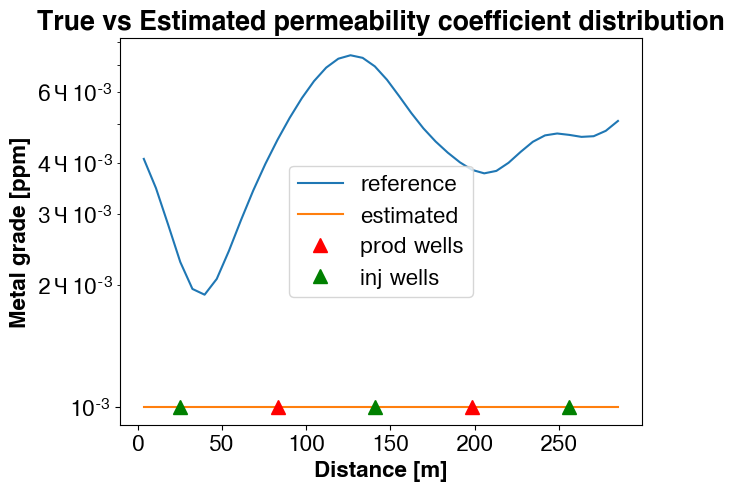

In [44]:
plotter = NestedGridPlotter()
ax = plotter.ax_dict["ax1-1"]

ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Metal grade [ppm]", fontweight="bold")
ax.set_yscale("log")
ax.set_title(
    "True vs Estimated permeability coefficient distribution", fontweight="bold"
)
plotter.fig.set_facecolor("w")


ax.plot(x_positions_in_meters, perm_reference_hytec[:, 0, 0, 0], label="reference")
ax.plot(x_positions_in_meters, perm_estimate_hytec[:, 0, 0, 0], label="estimated")

# Add some vertical lines to indicate the well
for well_pos in production_locations:
    ax.plot(
        well_pos * dx - dx / 2,
        min_val,
        label="prod wells",
        marker="^",
        markersize=10,
        c="r",
        linestyle="none",
    )

for well_pos in injection_locations:
    ax.plot(
        well_pos * dx - dx / 2,
        min_val,
        label="inj wells",
        marker="^",
        markersize=10,
        c="g",
        linestyle="none",
    )

plotter.add_axis_legend("ax1-1")

fname = "reference_vs_estimated_permeability_field_hytec"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

### Heads and darcy velocities

- spatial evolution of heads

In [45]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (12, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True)
    },
)

# Static plot
# for ax_name in ["ax1-1", "ax1-2"]:
#     plotter.get_axis(ax_name).plot(model_reference.c_init, c="red", label="Initial")

# Animated plot
nb_frames = 12

plotter.animated_multi_plot(
    ax_name="ax1-1",
    data={
        "Reference": {
            "x": x_positions_in_meters,
            "y": head_reference_hytec[:, 0, 0, :],
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x_positions_in_meters,
            "y": head_estimate_hytec[:, 0, 0, :],
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="HYTEC head",
    xlabel="X (m)",
    ylabel="[m]",
)

plotter.animated_multi_plot(
    ax_name="ax1-2",
    data={
        "Reference": {
            "x": x_positions_in_meters,
            "y": model_reference.fl_model.head[:, 0, :],
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x_positions_in_meters,
            "y": model_estimate.fl_model.head[:, 0, :],
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="PyRTID head",
    xlabel="X (m)",
)


# plot the time
def get_time() -> Generator[str, None, None]:
    ts_btw_frames = int(fwd_conc_estimate_hytec.shape[-1] / nb_frames)
    for frame in range(nb_frames):
        yield f"time = {grid_sample_times[ts_btw_frames * frame] / 3600:.3f} h"


for ax_name in ["ax1-1", "ax1-2"]:
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx
            - dx / 2,  # Well pos + 1 because of indexing that starts at zero
            c_min,
            label="prod wells",
            marker="^",
            markersize=10,
            c="r",
            linestyle="none",
        )

    for well_pos in injection_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx - dx / 2,
            0.0,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

    plotter.plot_animated_text(
        ax=plotter.get_axis(ax_name),
        x=0.83,
        y=0.92,
        s=list(get_time()),
        horizontalalignment="center",
        verticalalignment="center",
        transform=plotter.get_axis(ax_name).transAxes,
        fontsize=14,
        fontweight="bold",
    )

    plotter.add_axis_legend(ax_name, loc="lower left")

plotter.close()
plotter.animate(nb_frames=nb_frames)
# Save the animation locally on the computer
fname_html = fig_save_path.joinpath("true_vs_estimate_conc_animation.html")
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(fname_html, writer=writer)

# Extract the svg from the html file (for animation in Latex)
extract_frames_from_embedded_html_animation(fname_html)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


- spatial and temporal evolution of darcy velocities

In [46]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (12, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True)
    },
)

# Static plot
# for ax_name in ["ax1-1", "ax1-2"]:
#     plotter.get_axis(ax_name).plot(model_reference.c_init, c="red", label="Initial")

# Animated plot
nb_frames = min(nt, 30)

plotter.animated_multi_plot(
    ax_name="ax1-1",
    data={
        "Reference": {
            "x": x_positions_in_meters,
            "y": flowrate_reference_hytec[:, 0, 0, :],
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x_positions_in_meters,
            "y": flowrate_estimate_hytec[:, 0, 0, :],
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="HYTEC flowrates",
    xlabel="X (m)",
    ylabel="[m]",
)

plotter.animated_multi_plot(
    ax_name="ax1-2",
    data={
        "Reference": {
            "x": x_positions_in_meters,
            "y": model_reference.fl_model.u_darcy_x_center[:, 0, :],
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x_positions_in_meters,
            "y": model_estimate.fl_model.u_darcy_x_center[:, 0, :],
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="PyRTID flowrates",
    xlabel="X (m)",
)


# plot the time
def get_time() -> Generator[str, None, None]:
    ts_btw_frames = int(fwd_conc_estimate_hytec.shape[-1] / nb_frames)
    for frame in range(nb_frames):
        yield f"time = {grid_sample_times[ts_btw_frames * frame] / 3600:.3f} h"


for ax_name in ["ax1-1", "ax1-2"]:
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx
            - dx / 2,  # Well pos + 1 because of indexing that starts at zero
            c_min,
            label="prod wells",
            marker="^",
            markersize=10,
            c="r",
            linestyle="none",
        )

    for well_pos in injection_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx - dx / 2,
            0.0,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

    plotter.plot_animated_text(
        ax=plotter.get_axis(ax_name),
        x=0.83,
        y=0.92,
        s=list(get_time()),
        horizontalalignment="center",
        verticalalignment="center",
        transform=plotter.get_axis(ax_name).transAxes,
        fontsize=14,
        fontweight="bold",
    )

    plotter.add_axis_legend(ax_name, loc="lower left")

plotter.close()
plotter.animate(nb_frames=nb_frames)
# Save the animation locally on the computer
fname_html = fig_save_path.joinpath("true_vs_estimate_conc_animation.html")
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(fname_html, writer=writer)

# Extract the svg from the html file (for animation in Latex)
extract_frames_from_embedded_html_animation(fname_html)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


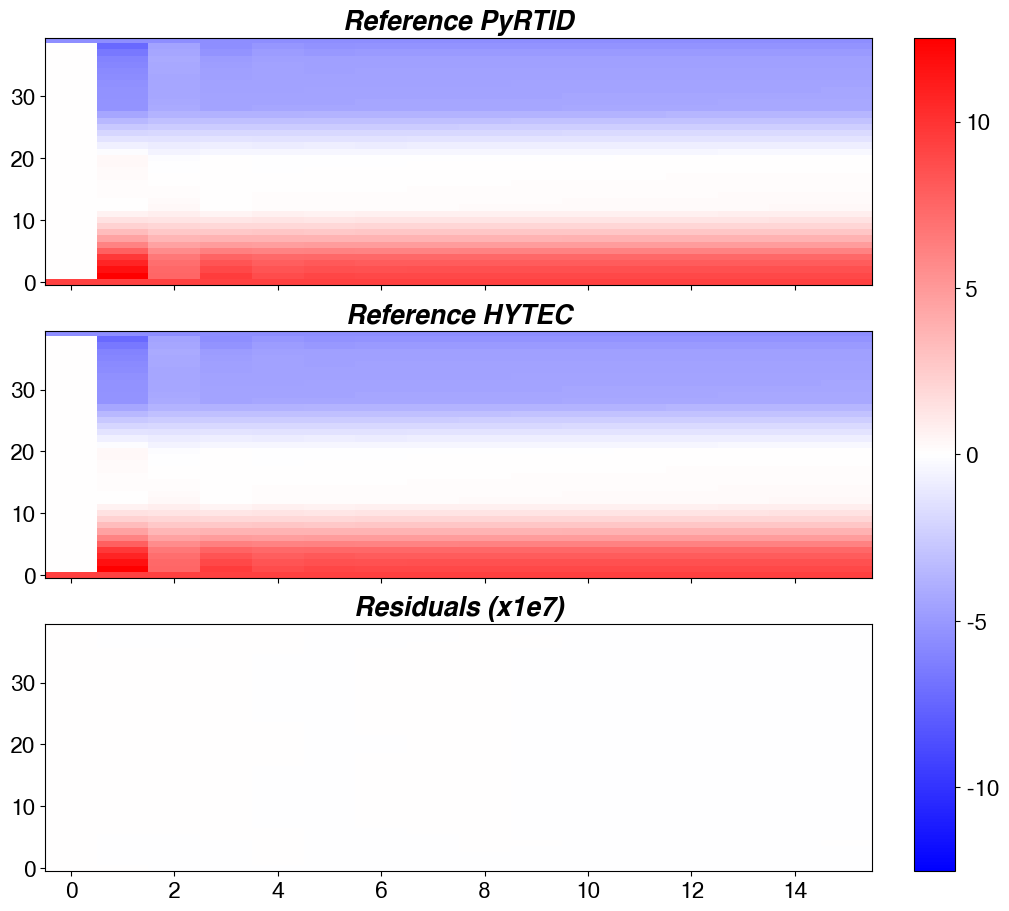

In [47]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 9)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax2-1"], ["ax3-1"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=list(plotter.ax_dict.values()),
    fig=plotter.fig,
    data={
        "Reference PyRTID": model_reference.fl_model.head[:, 0, :].T,
        "Reference HYTEC": head_reference_hytec[:, 0, 0, :].T,
        "Residuals (x1e7)": (
            model_reference.fl_model.head[:, 0, :].T
            - head_reference_hytec[:, 0, 0, :].T
        )
        * 1e7,
    },
    is_symetric_cbar=True,
)

fname = "tracer_concentration_true_vs_estimate_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

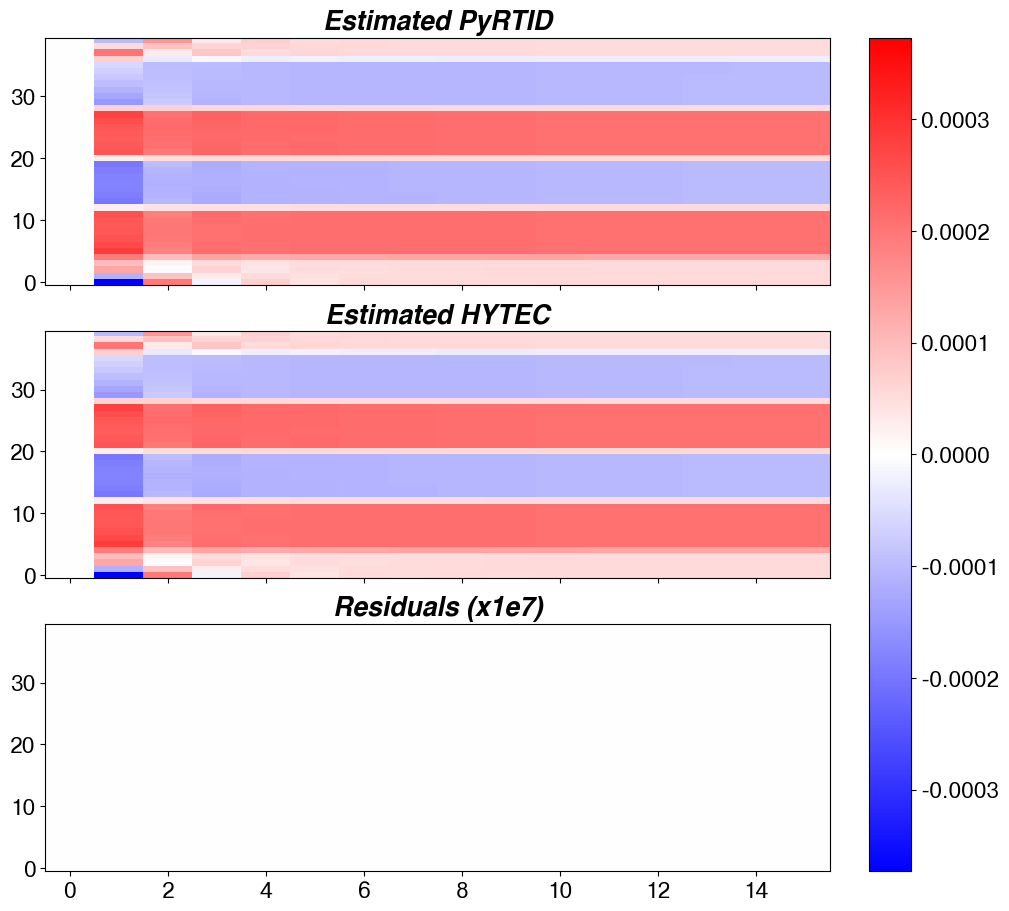

In [48]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 9)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax2-1"], ["ax3-1"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=list(plotter.ax_dict.values()),
    fig=plotter.fig,
    data={
        "Estimated PyRTID": model_estimate.fl_model.u_darcy_x_center[:, 0, :].T,
        "Estimated HYTEC": flowrate_estimate_hytec[:, 0, 0, :].T,
        "Residuals (x1e7)": (
            model_estimate.fl_model.u_darcy_x_center[:, 0, :].T
            - flowrate_estimate_hytec[:, 0, 0, :].T
        )
        * 1e7,
    },
    is_symetric_cbar=True,
)

fname = "tracer_concentration_true_vs_estimate_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

### Tracer concentrations

- Top view

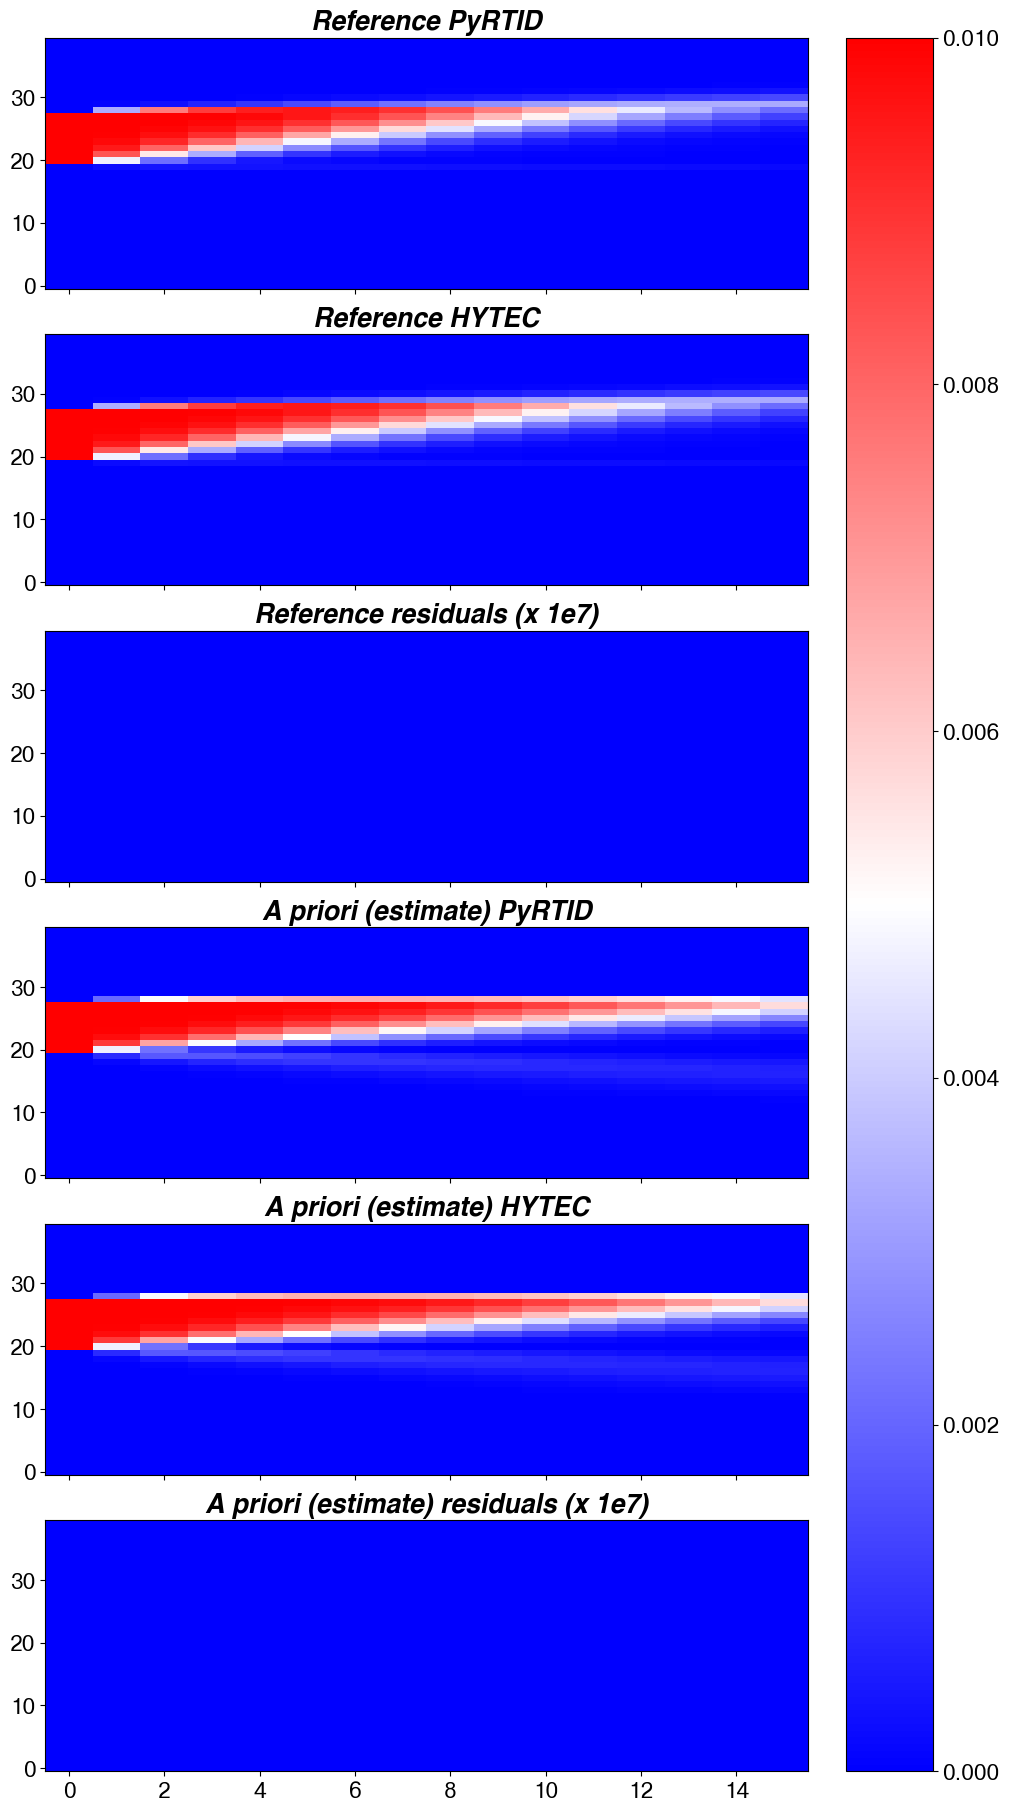

In [49]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 18)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"], ["ax3-1"], ["ax4-1"], ["ax5-1"], ["ax6-1"]],
            sharey=True,
            sharex=True,
        )
    },
)

multi_imshow(
    axes=list(plotter.ax_dict.values()),
    fig=plotter.fig,
    data={
        "Reference PyRTID": model_reference.tr_model.conc[:, 0, :].T,
        "Reference HYTEC": fwd_conc_reference_hytec[:, 0, 0, :].T,
        "Reference residuals (x 1e7)": (
            model_reference.tr_model.conc[:, 0, :].T
            - fwd_conc_reference_hytec[:, 0, 0, :].T
        )
        * 1e7,
        "A priori (estimate) PyRTID": model_estimate.tr_model.conc[:, 0, :].T,
        "A priori (estimate) HYTEC": fwd_conc_estimate_hytec[:, 0, 0, :].T,
        "A priori (estimate) residuals (x 1e7)": (
            model_estimate.tr_model.conc[:, 0, :].T
            - fwd_conc_estimate_hytec[:, 0, 0, :].T
        )
        * 1e7,
    },
)

fname = "tracer_concentration_true_vs_estimate_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Forward variables at the producer locations

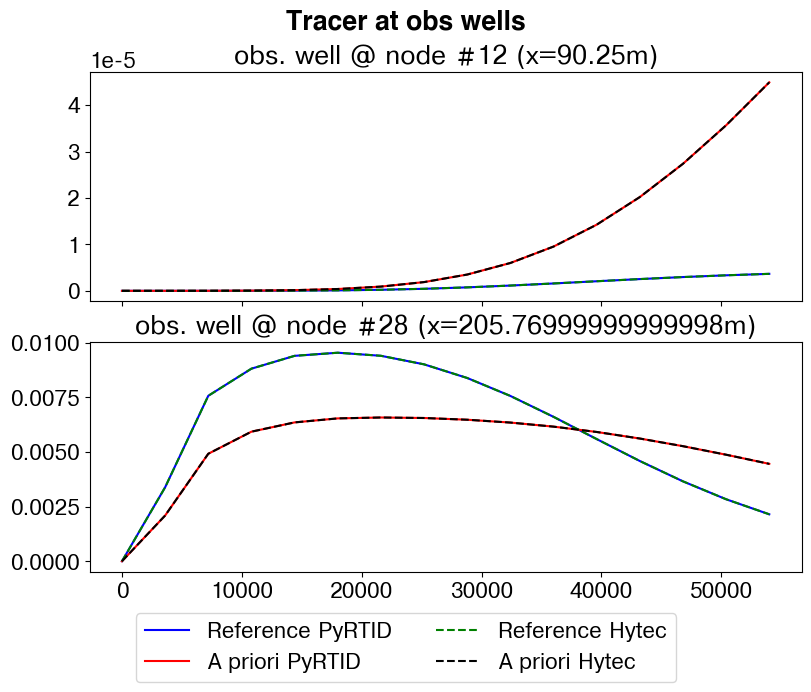

In [50]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (8, 6)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"]],
            sharey=False,
            sharex=True,
        )
    },
)

for i, node_id in enumerate(production_locations):
    ax = plotter.get_axis(f"ax{i + 1}-1")
    x = (node_id + 0.5) * geometry.dx
    obs_well_name = f"obs. well @ node #{node_id} (x={x}m)"

    ax.set_title(obs_well_name)
    ax.plot(
        np.arange(nt + 1) * dt,
        model_reference.tr_model.conc[node_id, 0, :],
        label="Reference PyRTID",
        c="b",
    )
    ax.plot(
        np.arange(nt + 1) * dt,
        model_estimate.tr_model.conc[node_id, 0, :],
        label="A priori PyRTID",
        c="r",
    )
    ax.plot(
        grid_sample_times,
        fwd_conc_reference_hytec[node_id, 0, 0, :],
        label="Reference Hytec",
        c="g",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        fwd_conc_estimate_hytec[node_id, 0, 0, :],
        label="A priori Hytec",
        c="k",
        linestyle="--",
    )

plotter.fig.suptitle("Tracer at obs wells", fontweight="bold")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.02)

fname = "tracer_concentration_true_vs_estimate_at_obs_1D"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

In [51]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (12, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2"]], sharey=True, sharex=True)
    },
)

# Animated plot
nb_frames = min(30, nt)

plotter.animated_multi_plot(
    ax_name="ax1-1",
    data={
        "True": {
            "x": x_positions_in_meters,
            "y": fwd_conc_reference_hytec[:, 0, 0, :],
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x_positions_in_meters,
            "y": fwd_conc_estimate_hytec[:, 0, 0, :],
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="HYTEC conc",
    xlabel="X (m)",
    ylabel="[mol/l]",
)

plotter.animated_multi_plot(
    ax_name="ax1-2",
    data={
        "True": {
            "x": x_positions_in_meters,
            "y": model_reference.tr_model.conc[:, 0, :],
            "kwargs": {"c": "blue"},
        },
        "Estimated": {
            "x": x_positions_in_meters,
            "y": model_estimate.tr_model.conc[:, 0, :],
            "kwargs": {"c": "green", "linestyle": "--"},
        },
    },
    nb_frames=nb_frames,
    title="Demonstrator conc",
    xlabel="X (m)",
)


# plot the time
def get_time() -> Generator[str, None, None]:
    ts_btw_frames = int(fwd_conc_estimate_hytec.shape[-1] / nb_frames)
    for frame in range(nb_frames):
        yield f"time = {grid_sample_times[ts_btw_frames * frame] / 3600:.3f} h"


for ax_name in ["ax1-1", "ax1-2"]:
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx
            - dx / 2,  # Well pos + 1 because of indexing that starts at zero
            c_min,
            label="prod wells",
            marker="^",
            markersize=10,
            c="r",
            linestyle="none",
        )

    for well_pos in injection_locations:
        plotter.get_axis(ax_name).plot(
            (well_pos + 1) * dx - dx / 2,
            c_min,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

    plotter.plot_animated_text(
        ax=plotter.get_axis(ax_name),
        x=0.83,
        y=0.92,
        s=list(get_time()),
        horizontalalignment="center",
        verticalalignment="center",
        transform=plotter.get_axis(ax_name).transAxes,
        fontsize=14,
        fontweight="bold",
    )

    plotter.add_axis_legend(ax_name)

plotter.close()
plotter.animate(nb_frames=nb_frames)
# Save the animation locally on the computer
fname_html = fig_save_path.joinpath("true_vs_estimate_conc_animation.html")
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Extract the svg from the html file (for animation in Latex)
extract_frames_from_embedded_html_animation(fname_html)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


## Inversion

- Create a function to add some noise to the observations

In [52]:
noise_std: float = 1e-7  # This is an absolute value
rng = np.random.default_rng(2021)


def get_white_noise(shape: Iterable[int]) -> NDArrayFloat:
    """
    Return the input with some added white noise.

    Note
    ----
    The parameters are hardcoded to be consistent in the notebook.
    Change the function directly.
    """
    mean_noise = 0.0  # mean
    return rng.normal(mean_noise, noise_std, shape)


# Generate a white noise
obs_noise: NDArrayFloat = get_white_noise(
    model_reference.tr_model.conc[production_locations, 0, :].shape
)

- Check the intensity of the noise

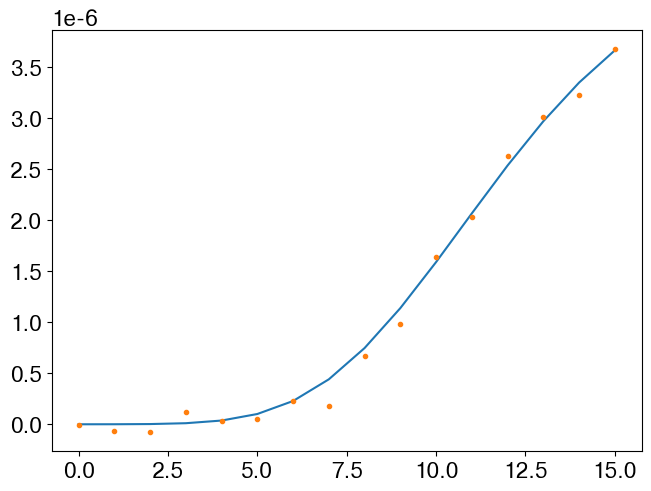

In [53]:
node_id = production_locations[0]
plt.figure(facecolor="w")
plt.plot(model_reference.tr_model.conc[node_id, 0, :])
plt.plot(
    model_reference.tr_model.conc[node_id, 0, :] + obs_noise[0],
    marker=".",
    linestyle="none",
)

### Demonstrator


In [54]:
def inverse_function(x: np.ndarray) -> np.ndarray:
    """Return 1/x."""
    return 1 / x


param = pyrtid.inverse.AdjustableParameter(
    name=pyrtid.inverse.ParameterName.PERMEABILITY,
    lbound=2e-6,
    ubound=5e-3,
    preconditioner=np.log,
    preconditioner_1st_derivative=inverse_function,
    backconditioner=np.exp,
)

from typing import Dict  # Just for linting

observables = []
for i, node_id in enumerate(production_locations):
    vals = model_reference.tr_model.conc[node_id, 0, :] + obs_noise[i]
    timesteps = np.arange(vals.shape[0])

    observables.append(
        pyrtid.inverse.Observable(
            state_variable=pyrtid.inverse.StateVariable.CONCENTRATION,
            location=(slice(node_id, node_id + 1, 1), slice(None)),
            timesteps=timesteps,
            values=vals,
            uncertainties=noise_std,
        )
    )


# Create an executor to keep track of the adjoint model
solver_config = dminv.ScipySolverConfig(
    solver_name="L-BFGS-B",
    solver_options={"maxfun": 20, "maxiter": 20, "ftol": 1e-4, "gtol": 1e-4},
    is_check_gradient=True,
)
model_adjusted = copy.deepcopy(model_estimate)
inverse_model = dminv.InverseModel(param, observables)
executor = dminv.ScipyInversionExecutor(model_adjusted, inverse_model, solver_config)


executor.scaled_loss_function(param.preconditioner(param.values))

is_grad_ok = executor.is_adjoint_gradient_correct()

INFO:root:- Running forward model # 1
INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 3392240352.069949
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 2.947904323435687e-10
INFO:root:Loss (scaled)         = 1.0



In [55]:
logging.info(f"Is the gradient correct: {is_grad_ok}")

INFO:root:Is the gradient correct: True


- Plot the first gradient

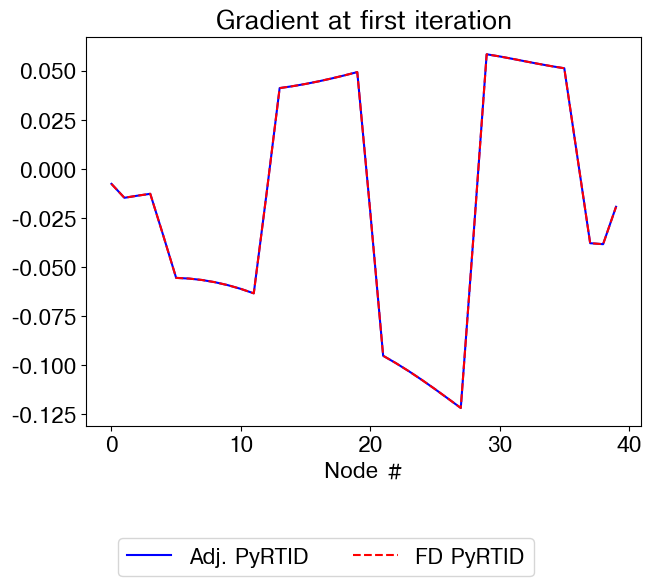

In [56]:
scaling_factor = executor.inv_model.scaling_factor

# Here comes the python code
plotter = NestedGridPlotter()

ax = plotter.get_axis("ax1-1")
ax.plot(
    param.archived_adjoint_gradients[0] * scaling_factor, label="Adj. PyRTID", c="b"
)
# ax.plot(my_gradient * scaling_factor, label="Adj. PyRTID", c="b")
ax.plot(
    param.archived_fd_gradients[0] * scaling_factor,
    label="FD PyRTID",
    c="r",
    linestyle="--",
)

ax.set_title("Gradient at first iteration")
ax.set_xlabel("Node #")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.1)

fname = "gradient_pyrtid_adj_vs_df_1d_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

In [57]:
v1 = param.archived_adjoint_gradients[0]
v2 = param.archived_fd_gradients[0]

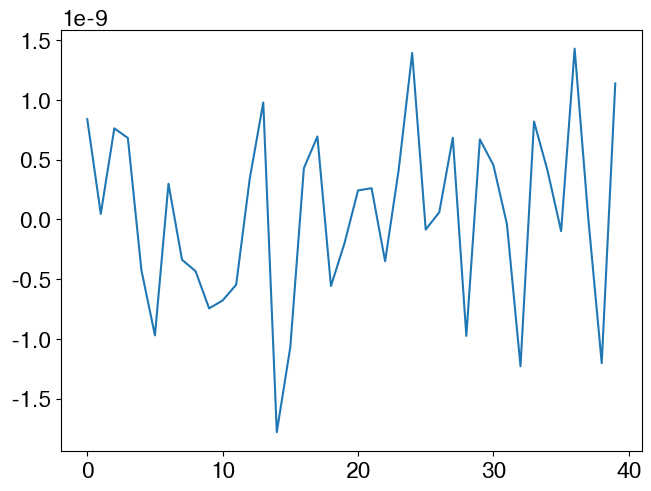

In [58]:
plt.plot((v1 - v2) * scaling_factor)

In [59]:
scale = np.maximum(np.maximum(np.abs(v1), np.abs(v2)), 1)
scale

array([[2.59034663e+07],
       [4.99405171e+07],
       [4.63542507e+07],
       [4.30645886e+07],
       [1.14815937e+08],
       [1.88393969e+08],
       [1.89568175e+08],
       [1.92062414e+08],
       [1.95873590e+08],
       [2.00995210e+08],
       [2.07415788e+08],
       [2.15116541e+08],
       [4.05479088e+07],
       [1.39675691e+08],
       [1.42960002e+08],
       [1.46845137e+08],
       [1.51289244e+08],
       [1.56237030e+08],
       [1.61615295e+08],
       [1.67326758e+08],
       [7.32915698e+07],
       [3.23033323e+08],
       [3.35961008e+08],
       [3.49928710e+08],
       [3.64851924e+08],
       [3.80568509e+08],
       [3.96832498e+08],
       [4.13290360e+08],
       [1.10878099e+08],
       [1.98096264e+08],
       [1.94417640e+08],
       [1.90227578e+08],
       [1.85862723e+08],
       [1.81577339e+08],
       [1.77564867e+08],
       [1.73973394e+08],
       [2.23912837e+07],
       [1.28420485e+08],
       [1.30161477e+08],
       [6.54992079e+07]])

In [60]:
eps = 1e-2
np.less_equal((np.abs(v1 - v2)), eps * scale)

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

### HYTEC

In [61]:
# 1) Copy the base simulation
simu_inverse = copy.deepcopy(simu_estimate)
simu_inverse.update_root_and_name(new_root="simu_inverse", new_name="simu_inverse")

# 2) Add the observation wells
for count, ix in enumerate(production_locations):
    x = (ix + 0.5) * geometry.dx
    zone_name = f"producer_{ix}"
    # zone = simu_inverse.model.get_sub_model(hymd.GeometryModel).get_zone(name)

    vals = fwd_conc_reference_hytec[ix, 0, 0, :] + obs_noise[count]

    # Add the observables for the area
    obs = Observable(
        zone_name=zone.name,
        state_variable=species,
        units="mol/kg",
        timesteps=grid_sample_times,
        time_units="s",
        obs_type=ObservationType.GRID,
        values=vals,
        uncertainties=np.ones(vals.size) * noise_std,
        node_numbers=np.ones(vals.size) * ix,
    )
    simu_inverse.register_observable(
        zone_name, obs, obs_file_path=f"observables/{zone_name}_{species}_o.dat"
    )

# 3) Update the htc file with some options
inv_model = hymd.InverseModel(
    hymd.OptimizationStatus("enabled"),
    hymd.OptimizationSolverConfig(
        "lbfgsb",
        hymd.AdjointStateStatus("enabled"),
        hymd.FdGradientCheck("initial"),
    ),
    hymd.AdjustedParameterConfig(
        "permeability",
        hymd.Lbound(1e-7, units="mol/kg"),
        hymd.Ubound(1e-2, units="mol/kg"),
        hymd.Preconditioner("logarithmic"),
    ),
)
simu_inverse.model.add_sub_item(inv_model)

# number of samples on the adjoint variables
simu_inverse.model.get_sub_model(hymd.SamplingModel).add_sub_item(
    hymd.AdjointGridSampling(nt)
)

# 4)Write the input files
simu_inverse.write_input_files()

runner.run(simu_inverse)

# 7) Read results
simu_inverse.read_hytec_results()  # This fails if not results have been written

INFO:root:The job is over ! Elapsed time = 0:00:04.504245


- Extract the adjoint variables computed for the first gradient

In [62]:
print(f"columns = {simu_inverse.handlers.results.optim_res.adjoint_var_columns}")

columns = ['timestep', 'Zones', 'node-number []', 'adjoint-variable{head} []', 'adjoint-variable{T} []', 'x-distance']


In [63]:
adj_conc_hytec = simu_inverse.handlers.results.extract_field_from_adj_var_res(
    field="adjoint-variable{T} []", nx=nx
)

In [64]:
adj_head_hytec = simu_inverse.handlers.results.extract_field_from_adj_var_res(
    field="adjoint-variable{head} []", nx=nx
)
adj_head_hytec.shape

(40, 1, 1, 16)

### Results comparison

The adjoint concentrations should be quite the same both in shape and intensity.

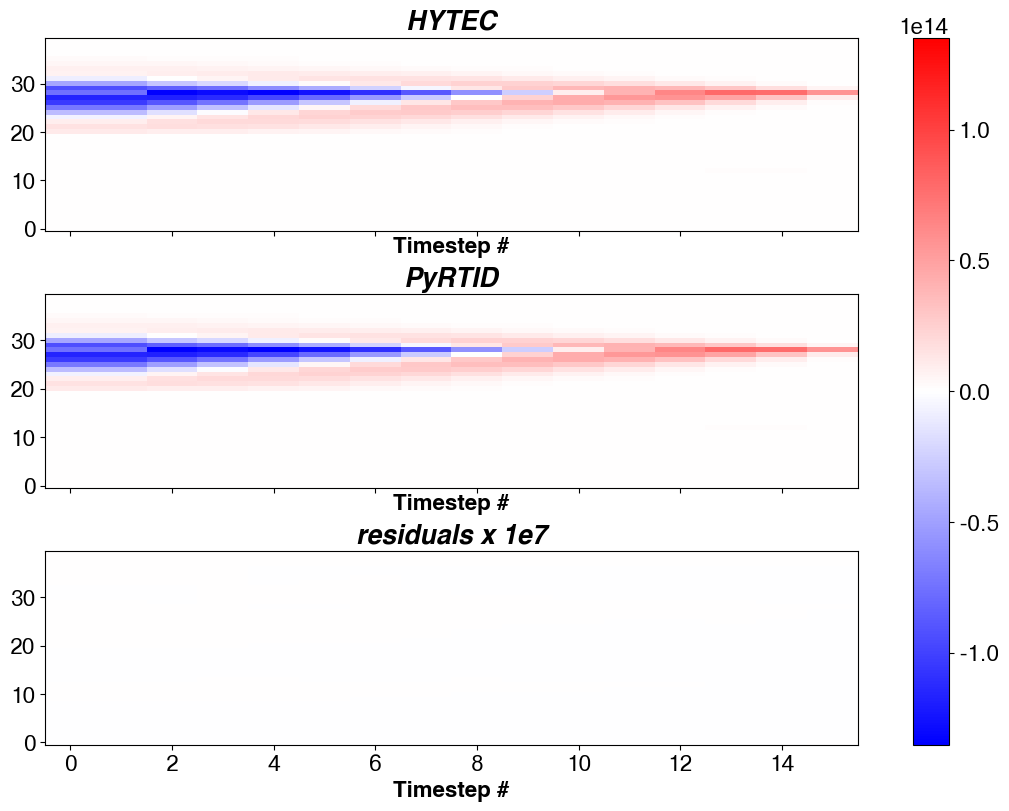

In [65]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 8)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax1-2"], ["ax1-3"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        "HYTEC": adj_conc_hytec[:, 0, 0, :].T,
        "PyRTID": executor.adj_model.tr_model.a_conc[:, 0, :].T,
        "residuals x 1e7": (
            adj_conc_hytec[:, 0, 0, :].T - executor.adj_model.tr_model.a_conc[:, 0, :].T
        )
        * 1e7,
    },
    xlabel="Timestep #",
    is_symetric_cbar=True,
)

fname = "adjoint_concentrations_dem_vs_hytec_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

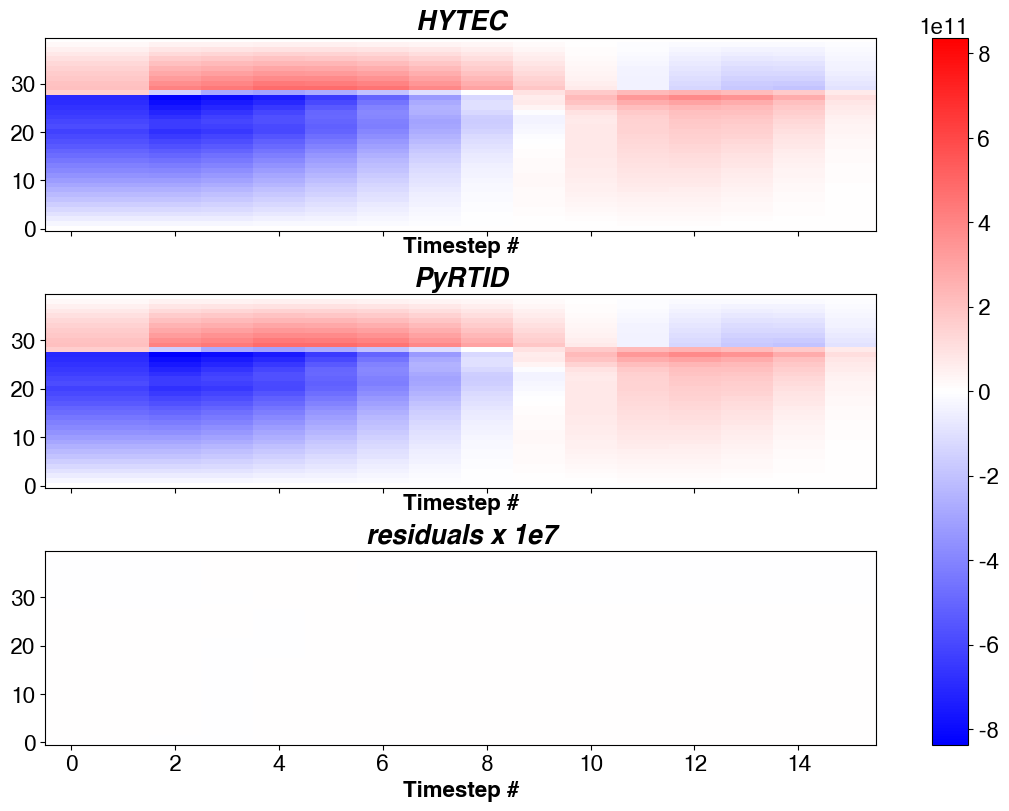

In [66]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 8)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax1-2"], ["ax1-3"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        "HYTEC": adj_head_hytec[:, 0, 0, :].T,
        "PyRTID": executor.adj_model.fl_model.a_head[:, 0, :].T,
        "residuals x 1e7": (
            adj_head_hytec[:, 0, 0, :].T - executor.adj_model.fl_model.a_head[:, 0, :].T
        )
        * 1e7,
    },
    xlabel="Timestep #",
    is_symetric_cbar=True,
)

fname = "adjoint_head_dem_vs_hytec_map"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

Let's check the adjoint variables at the three observation wells. Note that only the right one has been used as an adjoint source (node_id == 15).

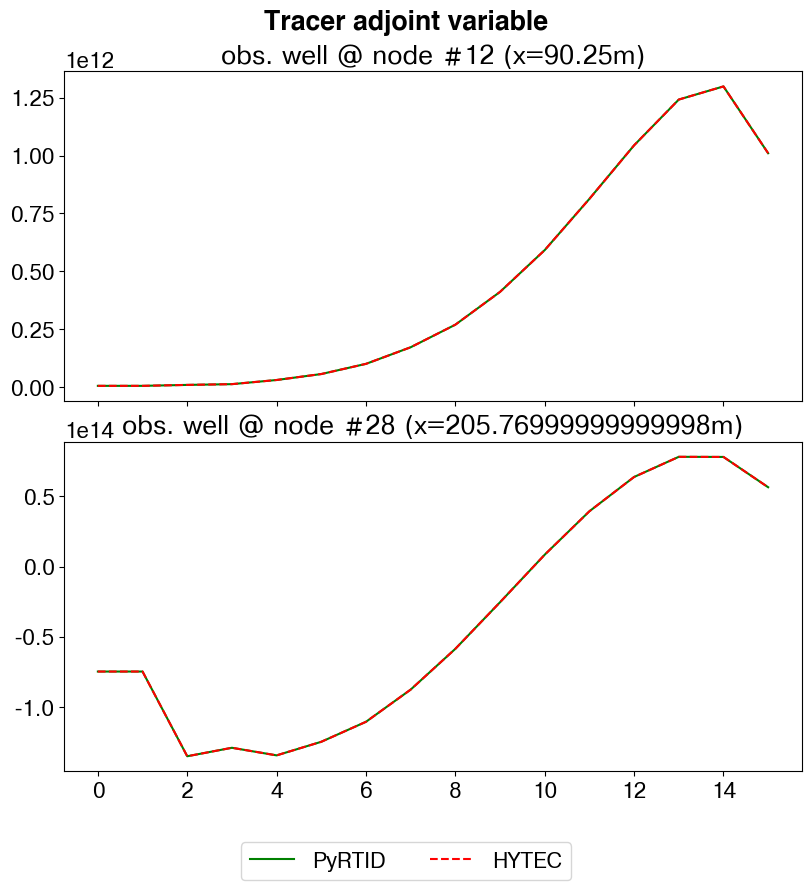

In [67]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (8, 8)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax2-1"]], sharey=False, sharex=True)
    },
)

for i, node_id in enumerate(production_locations):
    ax = plotter.get_axis(f"ax{i + 1}-1")
    x = (node_id + 0.5) * geometry.dx
    obs_well_name = f"obs. well @ node #{node_id} (x={x}m)"

    ax.set_title(obs_well_name)
    ax.plot(executor.adj_model.tr_model.a_conc[node_id, 0, :], label="PyRTID", c="g")
    ax.plot(adj_conc_hytec[node_id, 0, 0, :], label="HYTEC", c="r", linestyle="--")

plotter.fig.suptitle("Tracer adjoint variable", fontweight="bold")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.02)

fname = "adjoint_concentrations_dem_vs_hytec_1D"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Get the gradients by the adjoint method and finite differences

Finally, plot the gradients comparison.

In [68]:
# Get the HYTEC  Adj gradient
hytec_fd_gradient = simu_inverse.handlers.results.optim_res.fd_gradients[0]
hytec_adjoint_gradient = simu_inverse.handlers.results.optim_res.adjoint_gradients[0]

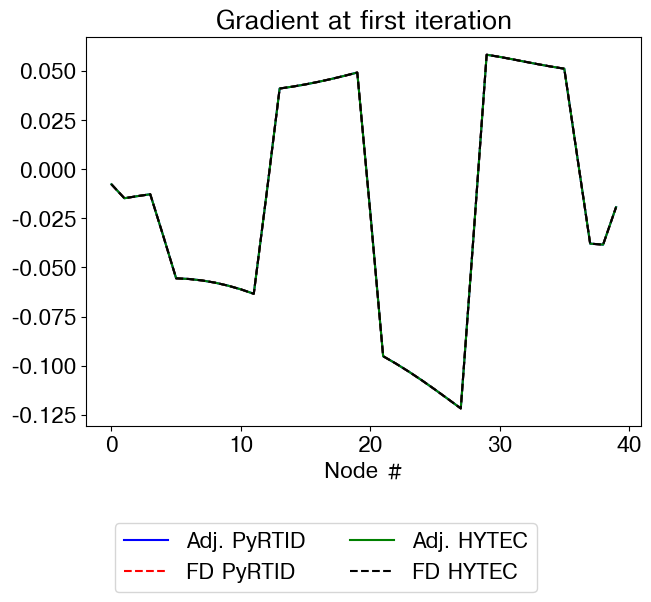

In [69]:
scaling_factor = executor.inv_model.scaling_factor

# Here comes the python code
plotter = NestedGridPlotter()

ax = plotter.get_axis("ax1-1")
ax.plot(
    param.archived_adjoint_gradients[0] * scaling_factor, label="Adj. PyRTID", c="b"
)
ax.plot(
    param.archived_fd_gradients[0] * scaling_factor,
    label="FD PyRTID",
    c="r",
    linestyle="--",
)
ax.plot(hytec_adjoint_gradient["value"], label="Adj. HYTEC", c="g")
ax.plot(hytec_fd_gradient["value"], label="FD HYTEC", c="k", linestyle="--")

ax.set_title("Gradient at first iteration")
ax.set_xlabel("Node #")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.1)

fname = "gradient_dem_vs_hytec_adj_vs_df_1d_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

In [70]:
param.archived_adjoint_gradients[0].ravel() * scaling_factor / hytec_adjoint_gradient[
    "value"
].ravel()

array([1.00000042, 0.99999909, 0.99999918, 1.00000221, 1.00000118,
       1.00000071, 0.99999971, 0.99999933, 0.99999931, 0.99999941,
       0.99999983, 0.99999997, 1.00000295, 0.99999896, 1.00000092,
       1.00000093, 1.00000048, 0.9999996 , 1.00000088, 1.00000055,
       0.99999784, 1.00000034, 0.99999991, 0.99999647, 0.99999865,
       0.9999996 , 1.00000362, 1.00000035, 1.00000009, 0.99999971,
       0.99999931, 0.99999947, 0.99999911, 0.99999929, 1.00000046,
       0.99999984, 0.99999943, 1.0000008 , 0.99999891, 1.000002  ])

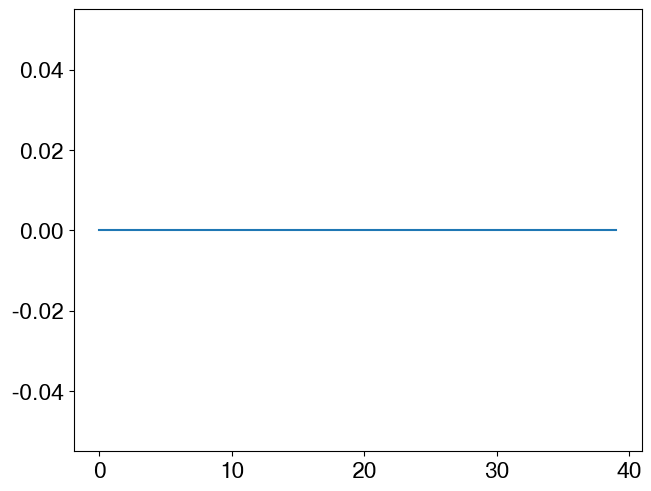

In [71]:
plt.plot(hytec_adjoint_gradient["value"] - hytec_fd_gradient["value"])